# SNF-simulations

This notebook contains some example code for the SNF simulations package.

## `Spectrum` example

Here, we create a `Spectrum` object for a single isotope, which encapsulates the antineutrino flux spectrum from the IAEA database.

In [1]:
from snf_simulations.spec import Spectrum

spec = Spectrum.from_isotope("Am242")
spec

<Spectrum "Am242", energy_range=(0.0-664.3 keV)>

The energy bins and flux values are stored in the `energy` and `flux` attributes of the `Spectrum` object, respectively. Energy is in keV, flux is antineutrinos per second per keV.

Note that there will be one more energy bin than flux values, since the bins are defined by upper and lower limits.

In [2]:
print(f"Energy bins: {len(spec.energy)}")
print(f"Flux values: {len(spec.flux)}")

Energy bins: 334
Flux values: 333


Now let's plot the spectrum.

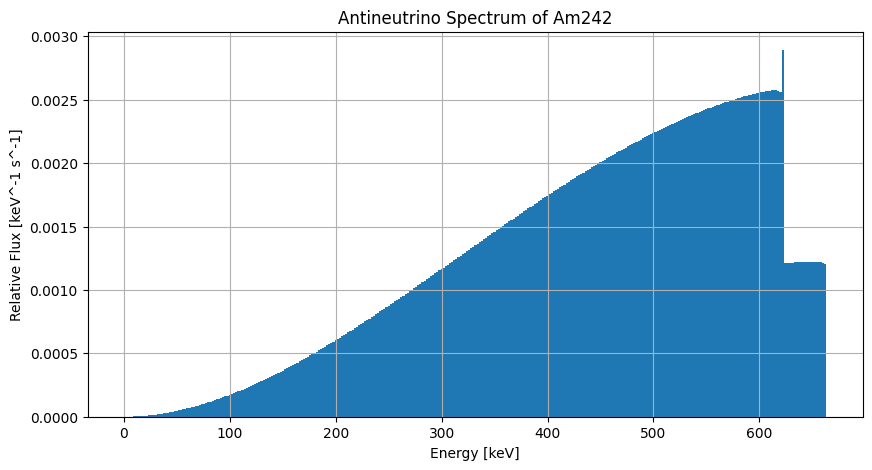

In [3]:
import matplotlib.pyplot as plt
import numpy as np

figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

# Plot the binned spectrum
axes.bar(x=spec.energy[:-1], height=spec.flux, width=np.diff(spec.energy))
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Antineutrino Spectrum of {spec.name}")
axes.grid()

plt.show()

## Single `Cask` example

Here, we generate a single cask of SNF from the Sizewell reactor. 

In order to simulate a cask, we need two properties:
* The mass of SNF, in kg
* The proportions of isotopes in the cask

For the latter, the proportions are currently defined for two sample reactors, Sizewell and Hartlepool. In the future different proportions should be able to be added using a FISPIN output file.

In [4]:
from snf_simulations.cask import Cask

# Create a Cask object
reactor = "sizewell"
mass = 10000  # 10 tonnes
cask = Cask.from_reactor(reactor, total_mass=mass)
cask

<Cask "sizewell_cask", total_mass=10000 kg>

We can get the combined antineutrino spectrum of all isotopes in the SNF and plot it.

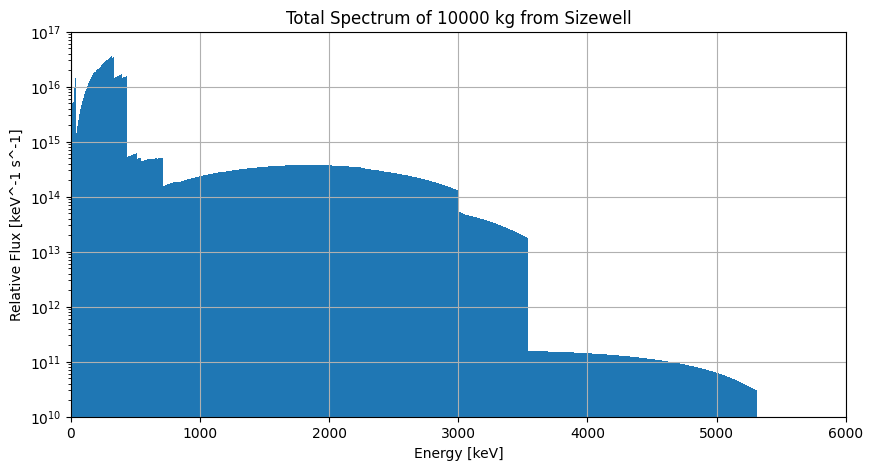

In [5]:
total_spec = cask.get_total_spectrum()

# Plot the spectrum
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

axes.bar(
    x=total_spec.energy[:-1], height=total_spec.flux, width=np.diff(total_spec.energy)
)

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e17)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Total Spectrum of {cask.total_mass} kg from {reactor.capitalize()}")
axes.set_yscale("log")
axes.grid()

plt.show()

We can also simulate the antineutrino spectrum from the SNF after any given removal time, which includes modeling the activity levels and decay chains.

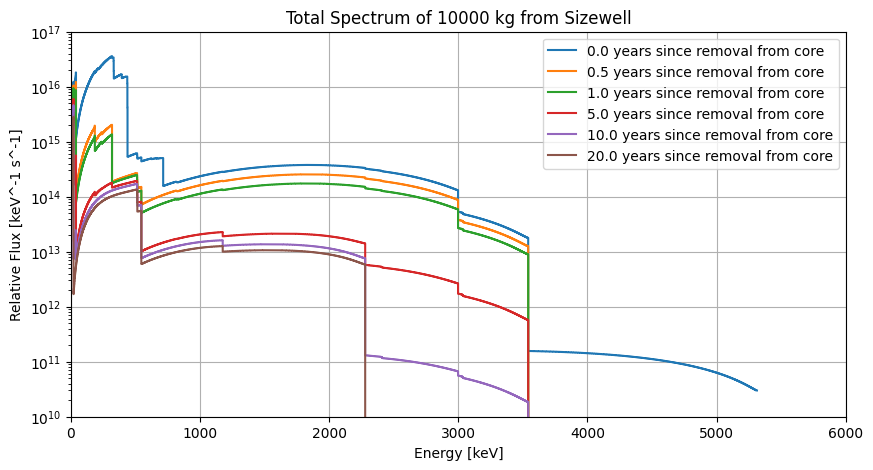

In [6]:
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

removal_times = [0, 0.5, 1, 5, 10, 20]
for removal_time in removal_times:
    total_spec = cask.get_total_spectrum(removal_time=removal_time)
    axes.step(
        total_spec.energy[:-1],
        total_spec.flux,
        where="post",
        label=f"{removal_time:.1f} years since removal from core",
    )

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e17)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Total Spectrum of {cask.total_mass} kg from {reactor.capitalize()}")
axes.set_yscale("log")
axes.grid()
axes.legend()

plt.show()

We can get a measure for the total flux above a given energy threshold by integrating the total spectrum. For inverse beta decay the threshold is 1.806 MeV, so we integrate above this energy to get the total flux of antineutrinos that can be detected.

We can then use the `calculate_flux_at_distance` function to calculate the flux at a given distance from the cask.

In [7]:
from snf_simulations.physics import calculate_flux_at_distance

removal_time = 0.5  # years
distance = 40  # meters

total_spec = cask.get_total_spectrum(removal_time=removal_time)
total_flux = total_spec.integrate(
    lower_energy=1806
)  # Integrate above the IBD threshold
flux = calculate_flux_at_distance(total_flux, distance)

print(
    f"Single {cask.total_mass / 1000:.0f}-tonne {reactor.capitalize()} cask "
    f"at {distance}m after {removal_time} years.:"
)
print("Antineutrino flux:")
print(f"  {flux:.3e} per cm2 per second")
print(f"  {flux * 60 * 60 * 24:.3e} per cm2 per day")

Single 10-tonne Sizewell cask at 40m after 0.5 years.:
Antineutrino flux:
  1.192e+09 per cm2 per second
  1.030e+14 per cm2 per day


Finally, we can calculate how that flux would convert into the number of events in our detector:

In [8]:
from snf_simulations.physics import calculate_event_rate

rate_lower, rate_upper = calculate_event_rate(flux, 0.2, 0.4)
print("Event rate in VIDARR detector:")
print(f"  {rate_lower:.3e} to {rate_upper:.3e} per second")
print(
    f"  {rate_lower * 60 * 60 * 24:.3f} to {rate_upper * 60**2 * 24:.3f} per day",
)

Event rate in VIDARR detector:
  1.773e-07 to 3.547e-07 per second
  0.015 to 0.031 per day


We can plot how the event rate varies with distance from the cask.

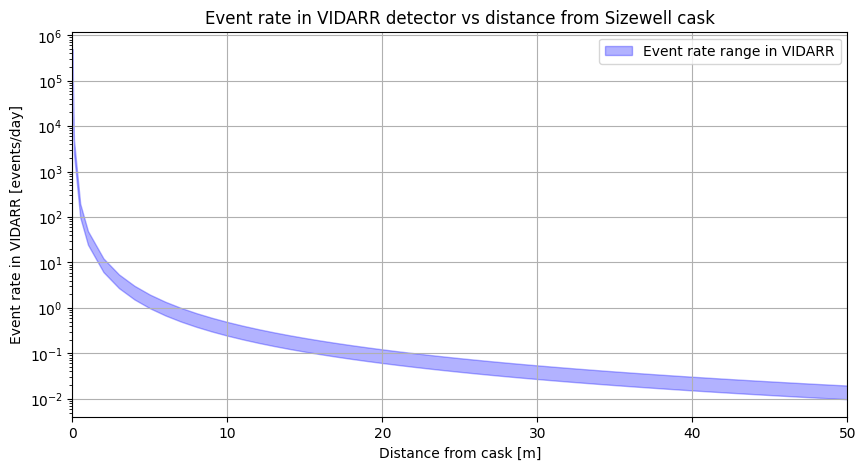

In [9]:
# Get a range of distances
distances = np.concatenate(([0.01, 0.05, 0.1, 0.5], np.linspace(1, 50, 50)))
removal_time = 0.5  # years

total_spec = cask.get_total_spectrum(removal_time=removal_time)
total_flux = total_spec.integrate(lower_energy=1806)
event_rates = []
for distance in distances:
    flux_at_distance = calculate_flux_at_distance(total_flux, distance)
    rate_lower, rate_upper = calculate_event_rate(flux_at_distance, 0.2, 0.4)
    event_rates.append((rate_lower * 60 * 60 * 24, rate_upper * 60 * 60 * 24))
event_rates = np.array(event_rates)

figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)
axes.fill_between(
    distances,
    event_rates[:, 0],
    event_rates[:, 1],
    color="blue",
    alpha=0.3,
    label="Event rate range in VIDARR",
)
axes.set_xlim(0, 50)
axes.set_xlabel("Distance from cask [m]")
axes.set_ylabel("Event rate in VIDARR [events/day]")
axes.set_title(
    f"Event rate in VIDARR detector vs distance from {reactor.capitalize()} cask"
)
axes.set_yscale("log")
axes.grid()
axes.legend()

plt.show()

Or we could plot how the event rate varies with time after removal from the reactor.

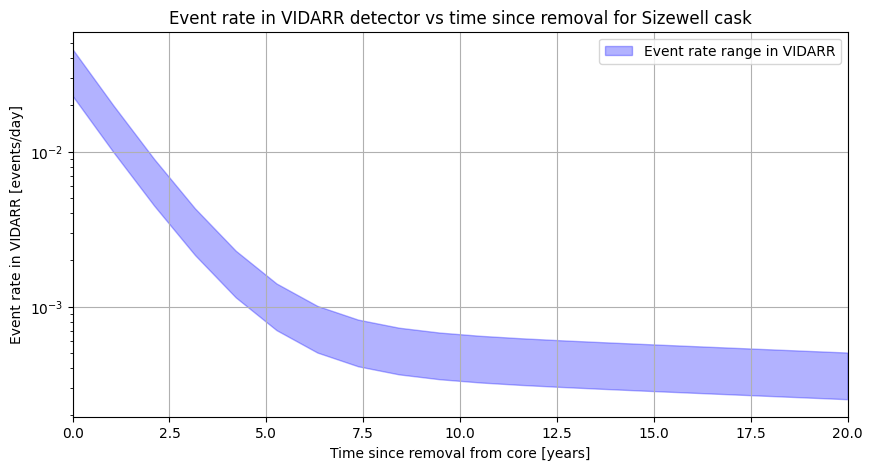

In [10]:
removal_times = np.linspace(0, 20, 20)  # years
distance = 40  # meters

event_rates = []
for removal_time in removal_times:
    total_spec = cask.get_total_spectrum(removal_time=removal_time)
    total_flux = total_spec.integrate(lower_energy=1806)
    flux_at_distance = calculate_flux_at_distance(total_flux, distance)
    rate_lower, rate_upper = calculate_event_rate(flux_at_distance, 0.2, 0.4)
    event_rates.append((rate_lower * 60 * 60 * 24, rate_upper * 60 * 60 * 24))
event_rates = np.array(event_rates)

figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)
axes.fill_between(
    removal_times,
    event_rates[:, 0],
    event_rates[:, 1],
    color="blue",
    alpha=0.3,
    label="Event rate range in VIDARR",
)
axes.set_xlim(0, 20)
axes.set_xlabel("Time since removal from core [years]")
axes.set_ylabel("Event rate in VIDARR [events/day]")
axes.set_title(
    f"Event rate in VIDARR detector vs time since removal "
    f"for {reactor.capitalize()} cask"
)
axes.set_yscale("log")
axes.grid()
axes.legend()

plt.show()

## Multiple `Cask` example

For a more complicated simulation, we can include multiple casks of SNF and look at the combined spectrum.

For example, we could assume 40 casks of SNF from the Sizewell reactor, with the following removal times:
* 10 casks removed 0.5 years ago
* 10 casks removed 5 years ago
* 10 casks removed 10 years ago
* 10 casks removed 20 years ago

Each cask has a mass of 10 tonnes.

To simplify the simulation, instead of simulating 10 individual 10-tonne casks for each removal time, we can just simulate one 100-tonne cask at each, since the total mass is the same.

As we're also assuming the isotopic proportions are the same for each cask, we can just create a single 100-tonne `Cask` object for the Sizewell reactor and use it for each removal time.

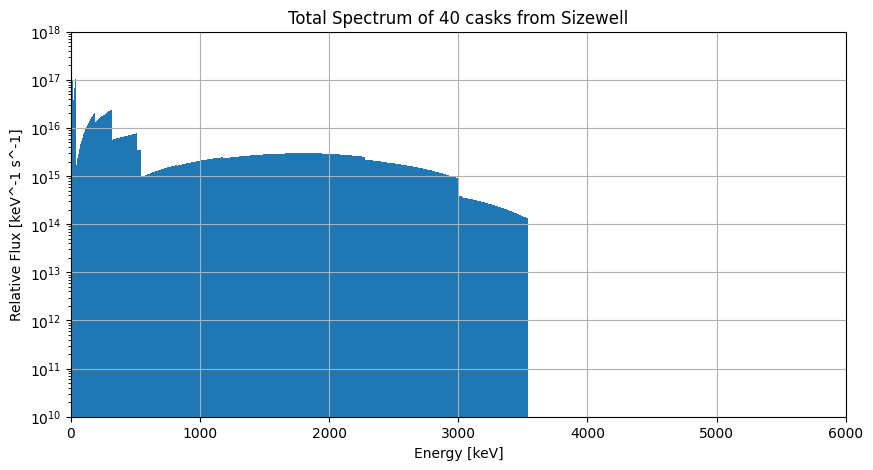

In [11]:
cask = Cask.from_reactor(
    "sizewell", total_mass=100000
)  # 100 tonnes = ten 10-tonne casks
removal_times = [0.5, 5, 10, 20]

spectra = []
for removal_time in removal_times:
    total_spec = cask.get_total_spectrum(removal_time=removal_time)
    spectra.append(total_spec)

# Now combine all the spectra into one by adding them together
spec_multiple = spectra[0]
for spec in spectra[1:]:
    spec_multiple = spec_multiple + spec

# Plot the spectrum
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

axes.bar(
    x=spec_multiple.energy[:-1],
    height=spec_multiple.flux,
    width=np.diff(spec_multiple.energy),
)

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e18)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Total Spectrum of 40 casks from {reactor.capitalize()}")
axes.set_yscale("log")
axes.grid()

plt.show()

We can also simulate how this total spectrum would decay over time.

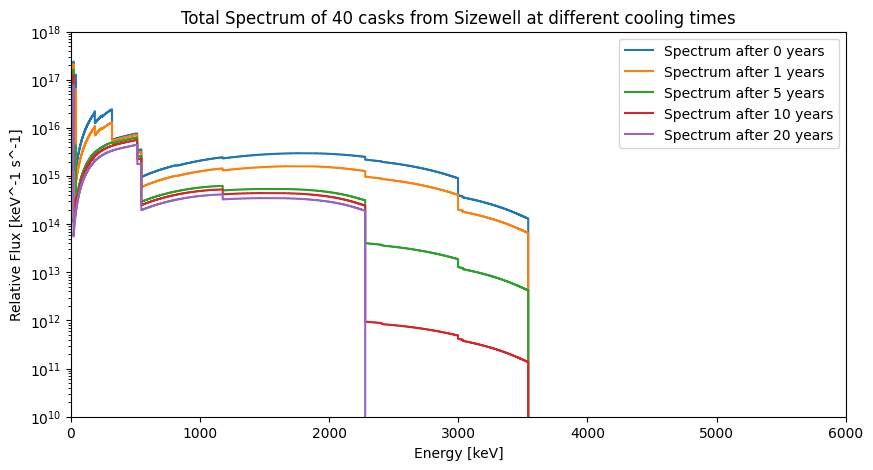

In [12]:
cask = Cask.from_reactor(
    "sizewell", total_mass=100000
)  # 100 tonnes = ten 10-tonne casks
cask_removal_times = [0.5, 5, 10, 20]
simulation_times = [0, 1, 5, 10, 20]

spectra = []
for simulation_time in simulation_times:
    new_ages = np.array(cask_removal_times) + simulation_time
    time_spectra = []
    for removal_time in new_ages:
        spec = cask.get_total_spectrum(removal_time=removal_time)
        time_spectra.append(spec)
    total_spec = time_spectra[0]
    for spec in time_spectra[1:]:
        total_spec = total_spec + spec
    spectra.append(total_spec)

# Plot the spectra
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

for spec, simulation_time in zip(spectra, simulation_times, strict=True):
    axes.step(
        spec.energy[:-1],
        spec.flux,
        where="post",
        label=f"Spectrum after {simulation_time} years",
    )

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e18)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(
    f"Total Spectrum of 40 casks from {reactor.capitalize()} at different cooling times"
)
axes.set_yscale("log")
axes.legend()

plt.show()